# Лабораторная работа — Метрики качества для классификации (завершённый вариант)

Notebook содержит законченный код: загрузка данных, предобработка, импутация, масштабирование, обучение KNN / DecisionTree / LogisticRegression, оценка по метрикам и визуализация ROC / PR кривых.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', 500)

print('pandas', pd.__version__)

pandas 2.3.3


In [3]:
data_path = './data/data_set.csv'

if not os.path.exists(data_path):
    print(f"Файл {data_path} не найден. Пожалуйста, помести CSV в папку ./data/ и перезапусти ноутбук.")
else:
    data = pd.read_csv(data_path, delimiter=';')
    print('Данные загружены. shape =', data.shape)
    display(data.head())


Данные загружены. shape = (15223, 52)


,AGREEMENT_RK,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,EDUCATION,MARITAL_STATUS,GEN_INDUSTRY,GEN_TITLE,ORG_TP_STATE,ORG_TP_FCAPITAL,JOB_DIR,FAMILY_INCOME,PERSONAL_INCOME,REG_ADDRESS_PROVINCE,FACT_ADDRESS_PROVINCE,POSTAL_ADDRESS_PROVINCE,TP_PROVINCE,REGION_NM,REG_FACT_FL,FACT_POST_FL,REG_POST_FL,REG_FACT_POST_FL,REG_FACT_POST_TP_FL,FL_PRESENCE_FL,OWN_AUTO,AUTO_RUS_FL,HS_PRESENCE_FL,COT_PRESENCE_FL,GAR_PRESENCE_FL,LAND_PRESENCE_FL,CREDIT,TERM,FST_PAYMENT,DL_DOCUMENT_FL,GPF_DOCUMENT_FL,FACT_LIVING_TERM,WORK_TIME,FACT_PHONE_FL,REG_PHONE_FL,GEN_PHONE_FL,LOAN_NUM_TOTAL,LOAN_NUM_CLOSED,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ,LOAN_AVG_DLQ_AMT,LOAN_MAX_DLQ_AMT,PREVIOUS_CARD_NUM_UTILIZED
0,59910150,0,49,1,0,1,2,1,Среднее специальное,Состою в браке,Торговля,Рабочий,Частная компания,Без участия,Вспомогательный техперсонал,от 10000 до 20000 руб.,5000,Оренбургская область,Оренбургская область,Оренбургская область,Оренбургская область,ПОВОЛЖСКИЙ,1,1,1,1,1,0,0,0,0,0,0,0,8000,6,8650,0,1,220,18.0,0,0,1,1,1,6,2,1,1580,1580,NaN
1,59910230,0,32,1,0,1,3,3,Среднее,Состою в браке,Торговля,Рабочий,Индивидуальный предприниматель,Без участия,Участие в основ. деятельности,от 10000 до 20000 руб.,12000,Кабардино-Балкария,Кабардино-Балкария,Кабардино-Балкария,Ставропольский край,ЮЖНЫЙ,1,1,1,1,0,0,0,0,0,0,0,0,21650,6,4000,0,1,137,97.0,1,0,1,1,1,6,1,1,4020,4020,NaN
2,59910525,0,52,1,0,1,4,0,Неполное среднее,Состою в браке,Информационные технологии,Специалист,Государственная комп./учреж.,Без участия,Участие в основ. деятельности,от 10000 до 20000 руб.,9000,Иркутская область,Иркутская область,Иркутская область,Иркутская область,ВОСТОЧНО-СИБИРСКИЙ,1,1,1,1,1,0,0,0,1,0,0,0,33126,12,4000,0,1,251,84.0,0,0,1,2,1,11,0,0,0,0,NaN
3,59910803,0,39,1,0,1,1,1,Высшее,Состою в браке,Образование,Руководитель среднего звена,Государственная комп./учреж.,Без участия,Участие в основ. деятельности,от 20000 до 50000 руб.,25000,Ростовская область,Ростовская область,Ростовская область,Ростовская область,ЮЖНЫЙ,0,1,0,0,1,1,0,0,0,0,0,0,"8491,82",6,5000,0,0,36,168.0,1,1,1,1,1,6,3,1,"1589,92333333333",1590,NaN
4,59911781,0,30,1,0,0,0,0,Среднее,Состою в браке,Государственная служба,Специалист,Государственная комп./учреж.,Без участия,Участие в основ. деятельности,от 10000 до 20000 руб.,12000,Кабардино-Балкария,Кабардино-Балкария,Кабардино-Балкария,Ставропольский край,ЮЖНЫЙ,1,1,1,1,0,0,0,0,1,0,0,0,21990,12,4000,0,1,83,101.0,1,0,1,2,1,16,2,1,"1152,15",2230,NaN


In [4]:
def preproc(df_input):
    drop_cols = ['EDUCATION', 'FACT_ADDRESS_PROVINCE', 'FAMILY_INCOME', 'GEN_INDUSTRY', 
                 'GEN_TITLE', 'JOB_DIR', 'MARITAL_STATUS', 'ORG_TP_FCAPITAL', 'REGION_NM', 
                 'REG_ADDRESS_PROVINCE', 'ORG_TP_STATE', 'POSTAL_ADDRESS_PROVINCE', 'TP_PROVINCE', 
                 'AGREEMENT_RK']

    df_temp = df_input.copy()
    cols_to_drop = [c for c in drop_cols if c in df_temp.columns]
    df_temp = df_temp.drop(cols_to_drop, axis=1)

    digit_cols = [c for c in ['LOAN_AVG_DLQ_AMT', 'LOAN_MAX_DLQ_AMT', 'CREDIT', 'FST_PAYMENT', 'PERSONAL_INCOME'] if c in df_temp.columns]
    if digit_cols:
        df_temp[digit_cols] = df_temp[digit_cols].replace(regex={',': '.'}).astype('float64')

    return df_temp

print('Функция preproc готова')


Функция preproc готова


In [5]:
if 'data' in globals():
    data_preproc = preproc(data)
    print('После предобработки shape =', data_preproc.shape)
    display(data_preproc.head())
else:
    print('Данные не загружены — пропускаем этот шаг.')


После предобработки shape = (15223, 38)


,TARGET,AGE,SOCSTATUS_WORK_FL,SOCSTATUS_PENS_FL,GENDER,CHILD_TOTAL,DEPENDANTS,PERSONAL_INCOME,REG_FACT_FL,FACT_POST_FL,REG_POST_FL,REG_FACT_POST_FL,REG_FACT_POST_TP_FL,FL_PRESENCE_FL,OWN_AUTO,AUTO_RUS_FL,HS_PRESENCE_FL,COT_PRESENCE_FL,GAR_PRESENCE_FL,LAND_PRESENCE_FL,CREDIT,TERM,FST_PAYMENT,DL_DOCUMENT_FL,GPF_DOCUMENT_FL,FACT_LIVING_TERM,WORK_TIME,FACT_PHONE_FL,REG_PHONE_FL,GEN_PHONE_FL,LOAN_NUM_TOTAL,LOAN_NUM_CLOSED,LOAN_NUM_PAYM,LOAN_DLQ_NUM,LOAN_MAX_DLQ,LOAN_AVG_DLQ_AMT,LOAN_MAX_DLQ_AMT,PREVIOUS_CARD_NUM_UTILIZED
0,0,49,1,0,1,2,1,5000.0,1,1,1,1,1,0,0,0,0,0,0,0,8000.00,6,8650.0,0,1,220,18.0,0,0,1,1,1,6,2,1,1580.000000,1580.0,NaN
1,0,32,1,0,1,3,3,12000.0,1,1,1,1,0,0,0,0,0,0,0,0,21650.00,6,4000.0,0,1,137,97.0,1,0,1,1,1,6,1,1,4020.000000,4020.0,NaN
2,0,52,1,0,1,4,0,9000.0,1,1,1,1,1,0,0,0,1,0,0,0,33126.00,12,4000.0,0,1,251,84.0,0,0,1,2,1,11,0,0,0.000000,0.0,NaN
3,0,39,1,0,1,1,1,25000.0,0,1,0,0,1,1,0,0,0,0,0,0,8491.82,6,5000.0,0,0,36,168.0,1,1,1,1,1,6,3,1,1589.923333,1590.0,NaN
4,0,30,1,0,0,0,0,12000.0,1,1,1,1,0,0,0,0,1,0,0,0,21990.00,12,4000.0,0,1,83,101.0,1,0,1,2,1,16,2,1,1152.150000,2230.0,NaN


In [6]:
if 'data_preproc' in globals():
    if 'TARGET' not in data_preproc.columns:
        raise KeyError('В данных отсутствует столбец TARGET')
    label_col = data_preproc.columns == 'TARGET'
    X = data_preproc.loc[:, ~label_col].values
    y = data_preproc.loc[:, label_col].values.flatten()
    print('X shape =', X.shape)
    print('y distribution:\n', pd.Series(y).value_counts())
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if len(np.unique(y))>1 else None)
    print('Split done. X_train shape =', X_train.shape, 'X_test shape =', X_test.shape)
else:
    print('Пропускаем train/test split — нет предобработанных данных')


X shape = (15223, 37)
y distribution:
 0    13411
1     1812
Name: count, dtype: int64
Split done. X_train shape = (10656, 37) X_test shape = (4567, 37)


In [7]:
if 'X_train' in globals():
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    imp = SimpleImputer(strategy='mean')
    imp.fit(X_train)
    X_train = imp.transform(X_train)
    X_test = imp.transform(X_test)
    ss = StandardScaler()
    ss.fit(X_train)
    X_train = ss.transform(X_train)
    X_test = ss.transform(X_test)
    print('Imputation and scaling completed.')
else:
    print('Нет разделения на train/test — пропускаем иммутацию и масштабирование')


Imputation and scaling completed.


In [8]:
if 'X_train' in globals():
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.linear_model import LogisticRegression
    knn = KNeighborsClassifier(n_neighbors=5)
    dt = DecisionTreeClassifier(criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=10)
    logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
    knn.fit(X_train, y_train)
    dt.fit(X_train, y_train)
    logreg.fit(X_train, y_train)
    print('Обучение завершено')
else:
    print('Пропущено обучение — нет данных')


Обучение завершено


In [9]:
if 'X_test' in globals():
    y_test_knn = knn.predict(X_test)
    y_test_dt = dt.predict(X_test)
    y_test_logreg = logreg.predict(X_test)
    if hasattr(knn, 'predict_proba'):
        y_test_proba_knn = knn.predict_proba(X_test)[:, 1]
    else:
        y_test_proba_knn = np.zeros(len(X_test))
    y_test_proba_dt = dt.predict_proba(X_test)[:, 1]
    y_test_proba_logreg = logreg.predict_proba(X_test)[:, 1]
    print('Примеры предсказаний (метки):')
    print('Truth  :', y_test[:10])
    print('kNN    :', y_test_knn[:10])
    print('DT     :', y_test_dt[:10])
    print('LogReg :', y_test_logreg[:10])
else:
    print('Нет X_test — пропускаем прогнозы')


Примеры предсказаний (метки):
Truth  : [0 0 0 0 0 0 0 0 0 0]
kNN    : [0 0 0 0 1 0 0 0 0 0]
DT     : [0 0 0 0 1 0 0 0 0 0]
LogReg : [0 0 0 0 0 0 0 0 0 0]


,TP,FP,FN,TN,Accuracy,Error rate,Precision,Recall,F1
kNN,30,79,514,3944,0.870155,0.129845,0.275229,0.055147,0.091884
DT,46,190,498,3833,0.849354,0.150646,0.194915,0.084559,0.117949
LogReg,5,7,539,4016,0.880447,0.119553,0.416667,0.009191,0.017986


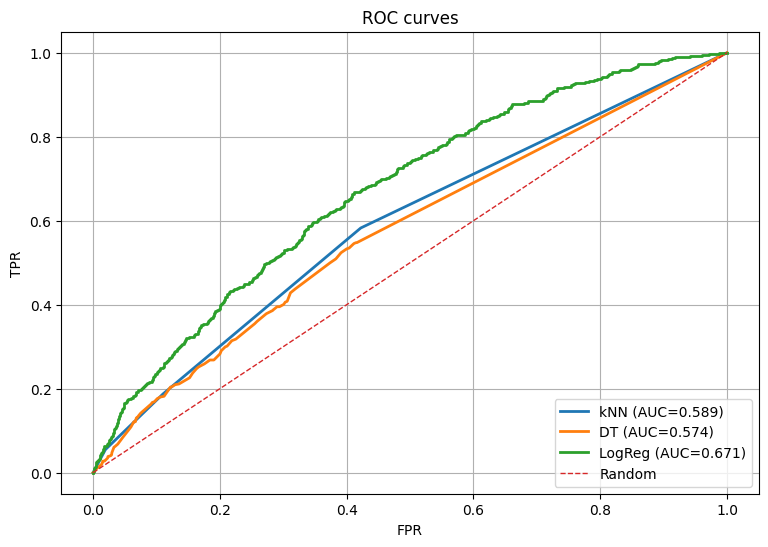

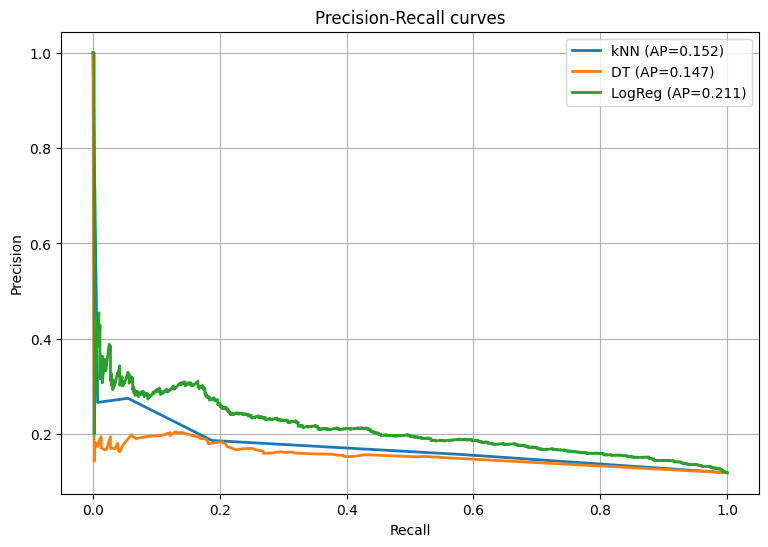

ROC AUC: kNN=0.5888, DT=0.5744, LogReg=0.6710
Average precision (AP): kNN=0.1517, DT=0.1472, LogReg=0.2111


In [10]:
if 'X_test' in globals():
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
    def quality_metrics_report(y_true, y_pred):
        tp = np.sum( (y_true == 1) & (y_pred == 1) )
        fp = np.sum( (y_true == 0) & (y_pred == 1) )
        fn = np.sum( (y_true == 1) & (y_pred == 0) )
        tn = np.sum( (y_true == 0) & (y_pred == 0) )
        accuracy = accuracy_score(y_true, y_pred)
        error_rate = 1 - accuracy
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        return [tp, fp, fn, tn, accuracy, error_rate, precision, recall, f1]
    metrics_report = pd.DataFrame(columns=['TP', 'FP', 'FN', 'TN', 'Accuracy', 'Error rate', 'Precision', 'Recall', 'F1'])
    metrics_report.loc['kNN', :] = quality_metrics_report(y_test, y_test_knn)
    metrics_report.loc['DT', :] = quality_metrics_report(y_test, y_test_dt)
    metrics_report.loc['LogReg', :] = quality_metrics_report(y_test, y_test_logreg)
    display(metrics_report)
    fpr_knn, tpr_knn, _ = roc_curve(y_test, y_test_proba_knn)
    auc_knn = auc(fpr_knn, tpr_knn)
    fpr_dt, tpr_dt, _ = roc_curve(y_test, y_test_proba_dt)
    auc_dt = auc(fpr_dt, tpr_dt)
    fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_test_proba_logreg)
    auc_logreg = auc(fpr_logreg, tpr_logreg)
    plt.figure(figsize=(9,6))
    plt.plot(fpr_knn, tpr_knn, linewidth=2, label=f'kNN (AUC={auc_knn:.3f})')
    plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f'DT (AUC={auc_dt:.3f})')
    plt.plot(fpr_logreg, tpr_logreg, linewidth=2, label=f'LogReg (AUC={auc_logreg:.3f})')
    plt.plot([0,1],[0,1], linestyle='--', linewidth=1, label='Random')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC curves')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()
    precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_test_proba_knn)
    ap_knn = average_precision_score(y_test, y_test_proba_knn)
    precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_test_proba_dt)
    ap_dt = average_precision_score(y_test, y_test_proba_dt)
    precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_test_proba_logreg)
    ap_logreg = average_precision_score(y_test, y_test_proba_logreg)
    plt.figure(figsize=(9,6))
    plt.plot(recall_knn, precision_knn, linewidth=2, label=f'kNN (AP={ap_knn:.3f})')
    plt.plot(recall_dt, precision_dt, linewidth=2, label=f'DT (AP={ap_dt:.3f})')
    plt.plot(recall_logreg, precision_logreg, linewidth=2, label=f'LogReg (AP={ap_logreg:.3f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curves')
    plt.legend(loc='best')
    plt.grid()
    plt.show()
    print('ROC AUC: kNN={:.4f}, DT={:.4f}, LogReg={:.4f}'.format(auc_knn, auc_dt, auc_logreg))
    print('Average precision (AP): kNN={:.4f}, DT={:.4f}, LogReg={:.4f}'.format(ap_knn, ap_dt, ap_logreg))
else:
    print('Нет X_test — пропускаем оценку')
